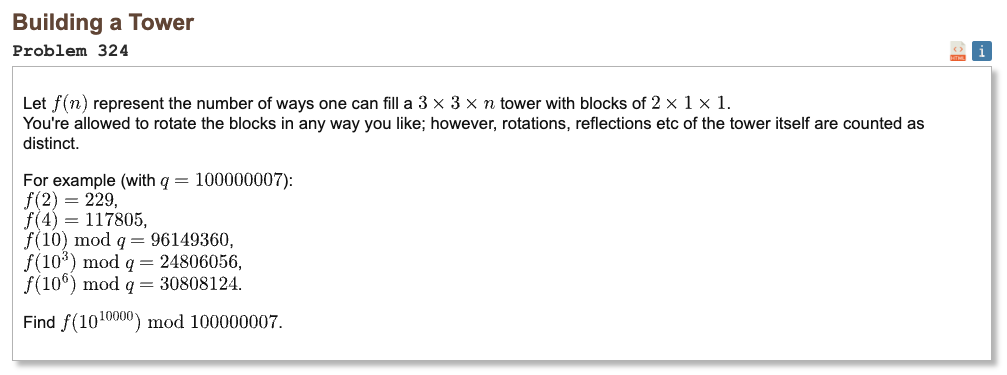

## Initial approach

* represent one tower layer as a nine-bit mask
* fill a layer using domino placements inside the layer or into the next layer
* generate the number of valid towers for many small heights
* the sequence follows a linear recurrence
* use Berlekamp-Massey to discover that recurrence automatically
* use fast linear recurrence exponentiation for the huge tower height
* print the result modulo the required number

In [1]:
MOD = 100000007
SIZE = 1 << 9

def next_masks_from(mask):
    results = []

    def rec(pos, current, next_mask):
        while pos < 9 and ((current >> pos) & 1):
            pos += 1

        if pos == 9:
            results.append(next_mask)
            return

        row, col = divmod(pos, 3)

        rec(pos + 1, current | (1 << pos), next_mask | (1 << pos))

        if col < 2 and not ((current >> (pos + 1)) & 1):
            rec(pos + 1, current | (1 << pos) | (1 << (pos + 1)), next_mask)

        if row < 2 and not ((current >> (pos + 3)) & 1):
            rec(pos + 1, current | (1 << pos) | (1 << (pos + 3)), next_mask)

    rec(0, mask, 0)
    return results

def generate_sequence(term_count):
    transitions = [next_masks_from(mask) for mask in range(SIZE)]

    dp = [0] * SIZE
    dp[0] = 1
    sequence = [1]

    for _ in range(term_count - 1):
        next_dp = [0] * SIZE

        for mask, value in enumerate(dp):
            if value:
                for next_mask in transitions[mask]:
                    next_dp[next_mask] = (next_dp[next_mask] + value) % MOD

        dp = next_dp
        sequence.append(dp[0])

    return sequence

def berlekamp_massey(sequence):
    c = [1]
    b = [1]
    length = 0
    m = 1
    last = 1

    for n in range(len(sequence)):
        discrepancy = sequence[n]

        for i in range(1, length + 1):
            discrepancy = (discrepancy + c[i] * sequence[n - i]) % MOD

        if discrepancy == 0:
            m += 1
            continue

        old_c = c[:]
        factor = discrepancy * pow(last, MOD - 2, MOD) % MOD

        if len(c) < len(b) + m:
            c += [0] * (len(b) + m - len(c))

        for j in range(len(b)):
            c[j + m] = (c[j + m] - factor * b[j]) % MOD

        if 2 * length <= n:
            length = n + 1 - length
            b = old_c
            last = discrepancy
            m = 1
        else:
            m += 1

    return [(-x) % MOD for x in c[1:]]

def nth_term(initial, coefficients, n):
    k = len(coefficients)

    if n < len(initial):
        return initial[n]

    def combine(a, b):
        temp = [0] * (2 * k)

        for i in range(k):
            if a[i]:
                for j in range(k):
                    if b[j]:
                        temp[i + j] = (temp[i + j] + a[i] * b[j]) % MOD

        for i in range(2 * k - 2, k - 1, -1):
            if temp[i]:
                for j in range(1, k + 1):
                    temp[i - j] = (temp[i - j] + temp[i] * coefficients[j - 1]) % MOD

        return temp[:k]

    result_poly = [1] + [0] * (k - 1)
    power_poly = [0] * k
    power_poly[1] = 1

    while n:
        if n & 1:
            result_poly = combine(result_poly, power_poly)

        power_poly = combine(power_poly, power_poly)
        n >>= 1

    total = 0

    for i in range(k):
        total = (total + result_poly[i] * initial[i]) % MOD

    return total

def solve():
    sequence = generate_sequence(500)

    assert sequence[2] == 229
    assert sequence[4] == 117805

    coefficients = berlekamp_massey(sequence)
    initial = sequence[:len(coefficients)]

    for i in range(200):
        assert nth_term(initial, coefficients, i) == sequence[i]

    return nth_term(initial, coefficients, 10 ** 10000)

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 96972774
CPU times: user 3.33 s, sys: 13.8 ms, total: 3.34 s
Wall time: 3.34 s
